# How the classifier works: from a scanned page to a match decision

A walkthrough of the algorithm in [`code/python`](../../code/python):
turn a scanned page into a 1D profile, then compare profiles to decide
if two pages match.

See `morphological_filter_theory.ipynb` for the dilation/erosion/opening/closing basics.

Example page: `data/templates/key/91856041_6049.png`, one of this
project's two enrolled keys.

In [1]:
import sys
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt

CODE_PYTHON = Path("../../code/python").resolve()
sys.path.insert(0, str(CODE_PYTHON))

from filters import read_image_gray, background_residual, line_filtered, profile_from_filtered, resample_profile
from peaks import extract_sharp_peak_positions, peak_set_mismatch_score
from keys import load_keys, DEFAULT_KEYS_DIR
from classify import classify_image

plt.rcParams["figure.figsize"] = (10, 3)
np.set_printoptions(precision=3, suppress=True)

IMAGE_PATH = DEFAULT_KEYS_DIR / "91856041_6049.png"
image = read_image_gray(IMAGE_PATH)

## 1. Removing the background

A page mixes shading, ruled lines, and text, at different scales. A
**square opening** ($k_1{=}20$, $k_2{=}15$ box) estimates the slowly-varying
shading; subtracting it leaves mostly lines + text. This is
`filters.background_residual`.

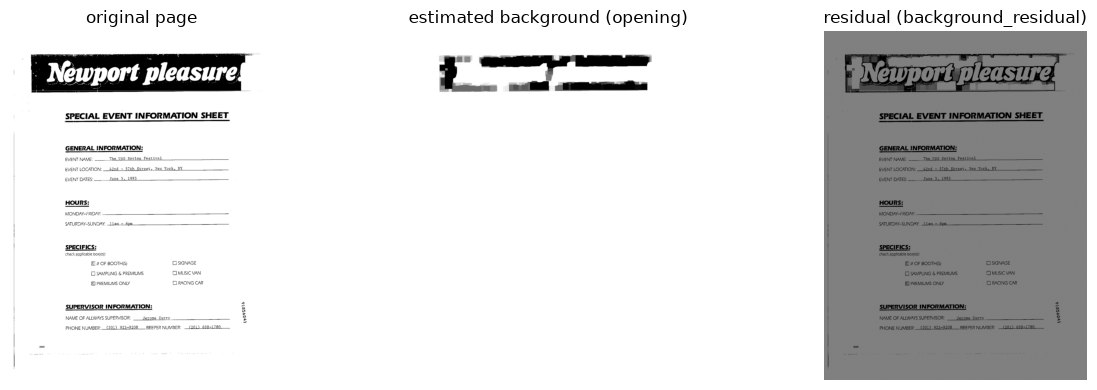

In [2]:
k1, k2 = 20, 15
background = cv2.erode(
    cv2.dilate(image, np.ones((k1, k1), np.uint8)),
    np.ones((k2, k2), np.uint8),
)
residual = background_residual(image, dilate_ksize=k1, erode_ksize=k2)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, im, title in zip(
    axes, [image, background, residual],
    ["original page", "estimated background (opening)", "residual (background_residual)"],
):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Isolating the ruled lines

Dilate with a thin **line** kernel — this bridges gaps *along the
line*, so a long ruled line survives while short text strokes just
smear into a blob. Erode with a small box afterward to clean that blob
away. Key `91856041_6049` checks horizontal lines (`use_h=True`).

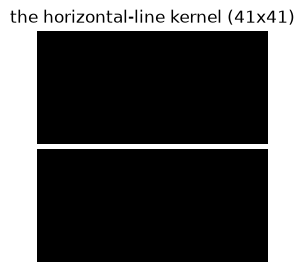

In [3]:
line_half_len = 20
m = 2 * line_half_len + 1
line_kernel = np.zeros((m, m), np.uint8)
line_kernel[line_half_len, :] = 1  # one full row -> detects horizontal lines

plt.imshow(line_kernel, cmap="gray")
plt.title(f"the horizontal-line kernel ({m}x{m})")
plt.axis("off")
plt.show()

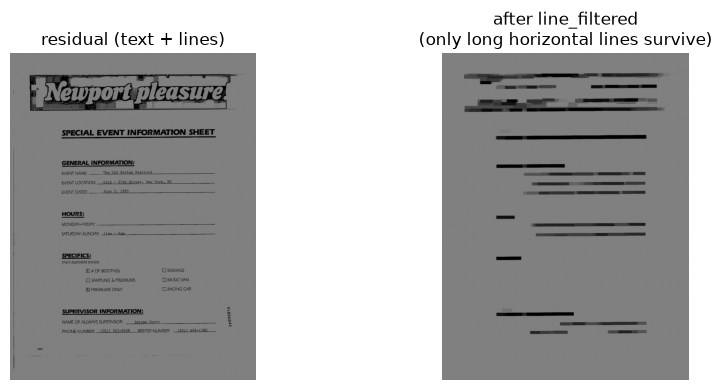

In [4]:
filtered_h = line_filtered(residual, "horizontal")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, im, title in zip(
    axes, [residual, filtered_h],
    ["residual (text + lines)", "after line_filtered\n(only long horizontal lines survive)"],
):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

> `background_residual` wraps around `mod 256` in `uint8` arithmetic
> instead of clipping at 0 — likely an unintended quirk of the original
> code, kept as-is since every key was built with that exact behavior.

## 3. Collapsing to a line profile

Sum $(255 - \text{filtered})$ across each row: a row with a ruled line
spikes, an empty row stays near 0.

$$
p[i] \;=\; \frac{1}{255 \cdot W} \sum_{j=1}^{W} \big(255 - \text{filtered}[i, j]\big)
$$

A line profile is much smaller than the image and easy to compare
directly — and after resampling, its length no longer depends on page
size. We've now turned "is there a horizontal line here" into one
number per row: real, quantitative data.

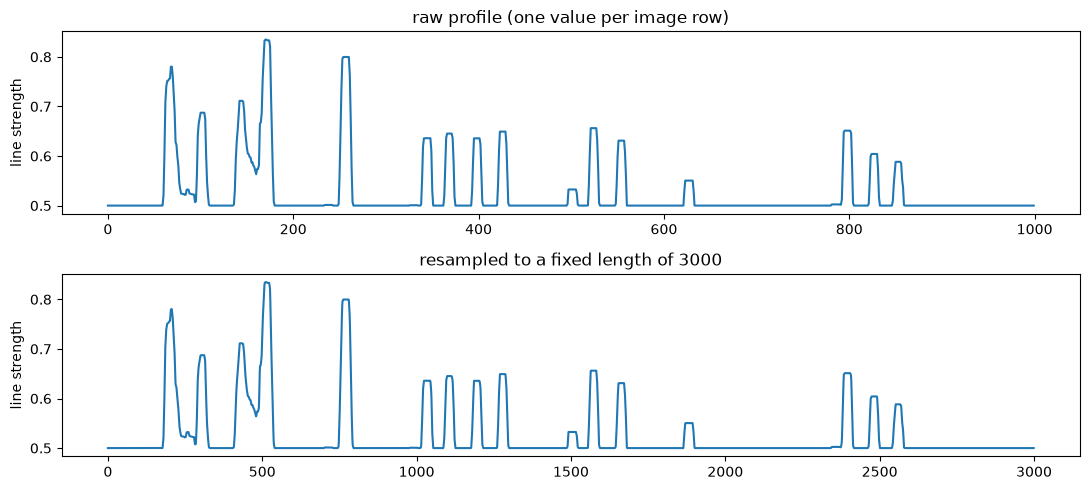

raw profile length: 1000 (= image height)  ->  resampled to 3000


In [5]:
profile = profile_from_filtered(filtered_h, "horizontal")
profile_resampled = resample_profile(profile)

fig, axes = plt.subplots(2, 1, figsize=(11, 5))
axes[0].plot(profile)
axes[0].set_title("raw profile (one value per image row)")
axes[1].plot(profile_resampled)
axes[1].set_title(f"resampled to a fixed length of {len(profile_resampled)}")
for ax in axes:
    ax.set_ylabel("line strength")
plt.tight_layout()
plt.show()

print(f"raw profile length: {len(profile)} (= image height)  ->  resampled to {len(profile_resampled)}")

## 4. What can you do with a line profile?

Once a page is a 1D profile, you can compare, cluster, or classify it.
This project's method: find the horizontal lines (peaks), then decide a
page's form from where those peaks sit and how many line up with a
known key.

## 5. Peaks and matching

Threshold the profile, group nearby crossings into peaks, keep the
narrow ("sharp") ones — a real ruled line gives a narrow spike, noise
gives a wide one. Compare two peak sets by matching each peak to the
closest one within 50 samples; every unmatched peak adds to the score.
Score 0 = same layout.

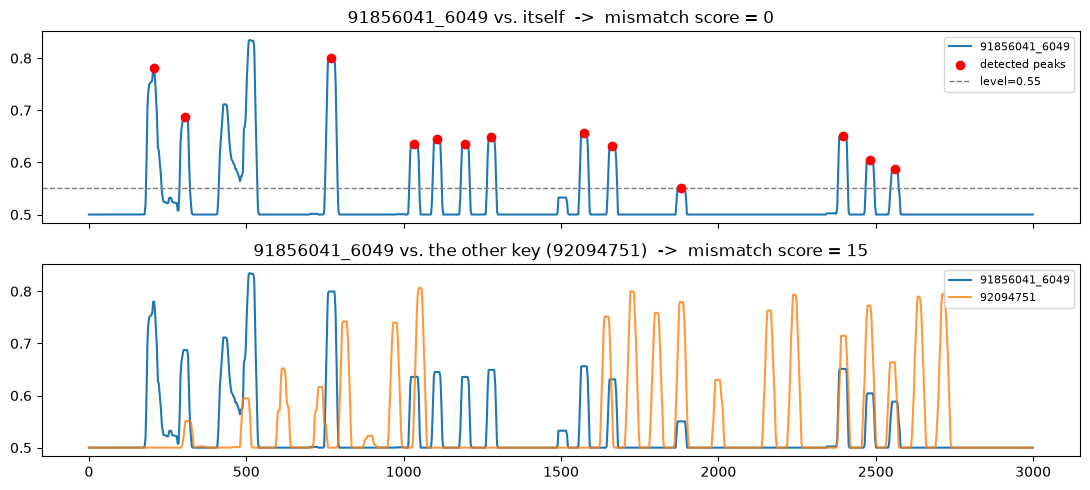

mismatch score, vs itself:    0
mismatch score, vs other key: 15


In [6]:
keys = load_keys()
by_id = {k.key_id: k for k in keys}

this_key = by_id["91856041_6049"]
other_key = by_id["92094751"]

peaks_self = extract_sharp_peak_positions(this_key.profile_h, this_key.level_h)

score_same = peak_set_mismatch_score(this_key.profile_h, this_key.profile_h, level=this_key.level_h)
score_diff = peak_set_mismatch_score(this_key.profile_h, other_key.profile_h, level=this_key.level_h)

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(this_key.profile_h, label="91856041_6049", color="tab:blue")
axes[0].scatter(peaks_self, [this_key.profile_h[i] for i in peaks_self], color="red", zorder=3, label="detected peaks")
axes[0].axhline(this_key.level_h, color="gray", linestyle="--", linewidth=1, label=f"level={this_key.level_h}")
axes[0].set_title(f"91856041_6049 vs. itself  ->  mismatch score = {score_same:.0f}")
axes[0].legend(loc="upper right", fontsize=8)

axes[1].plot(this_key.profile_h, label="91856041_6049", color="tab:blue")
axes[1].plot(other_key.profile_h, label="92094751", color="tab:orange", alpha=0.8)
axes[1].set_title(f"91856041_6049 vs. the other key (92094751)  ->  mismatch score = {score_diff:.0f}")
axes[1].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

print(f"mismatch score, vs itself:    {score_same:.0f}")
print(f"mismatch score, vs other key: {score_diff:.0f}")

## 6. `classify_image`

Compute a page's profile, score it against every key on whichever
orientation(s) that key checks, and report every key below the match
threshold. Two of these are real FUNSD pages, found by testing the
whole gallery against the keys.

In [7]:
test_images = [
    IMAGE_PATH,  # itself -> match
    Path("../../data/templates/funsd/92094746.png"),  # a different scanned page -> matches key 92094751
    Path("../../data/templates/funsd/82253362_3364.png"),  # unrelated page -> no match
]

for path in test_images:
    result = classify_image(path, keys)
    print(f"{path.name:20s} match={result.is_match!s:5}  best_class={result.best_class}")
    for m in result.matches:
        print(f"    matched key={m.key_id}  score_h={m.score_h}")

91856041_6049.png    match=True   best_class=91856041_6049
    matched key=91856041_6049  score_h=0.0


92094746.png         match=True   best_class=92094751
    matched key=92094751  score_h=2.0


82253362_3364.png    match=False  best_class=None


## 7. Why think classically here?

- **Understandable.** Every step above is inspectable — you can see
  exactly why a page did or didn't match, not guess at a black box.
- **Works with little data.** No training set, just a handful of
  enrolled keys.
- **No labels needed.** Even unlabeled, it can group similar-looking
  forms together.
- **New classes are free.** Add a new key any time — no retraining.